<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan6_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# NAMA  : SEPTIAN AL RIZKI
# NIM   : 230401010262
# KELAS : IF 401

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Setup tema visual
sns.set_theme(style='whitegrid', palette='muted')

=== LANGKAH 1: MUAT DATA & EKSPLORASI AWAL (EDA) ===
1. Info & Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    891 non-null    int64  
 1   sex       891 non-null    object 
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
 6   embarked  889 non-null    object 
 7   survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

2. Missing Values (Data Kosong):
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

3. Distribusi Target (Survived):
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


/tmp/ipykernel_9211/1898042190.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', palette='Set1', ax=axes[0])


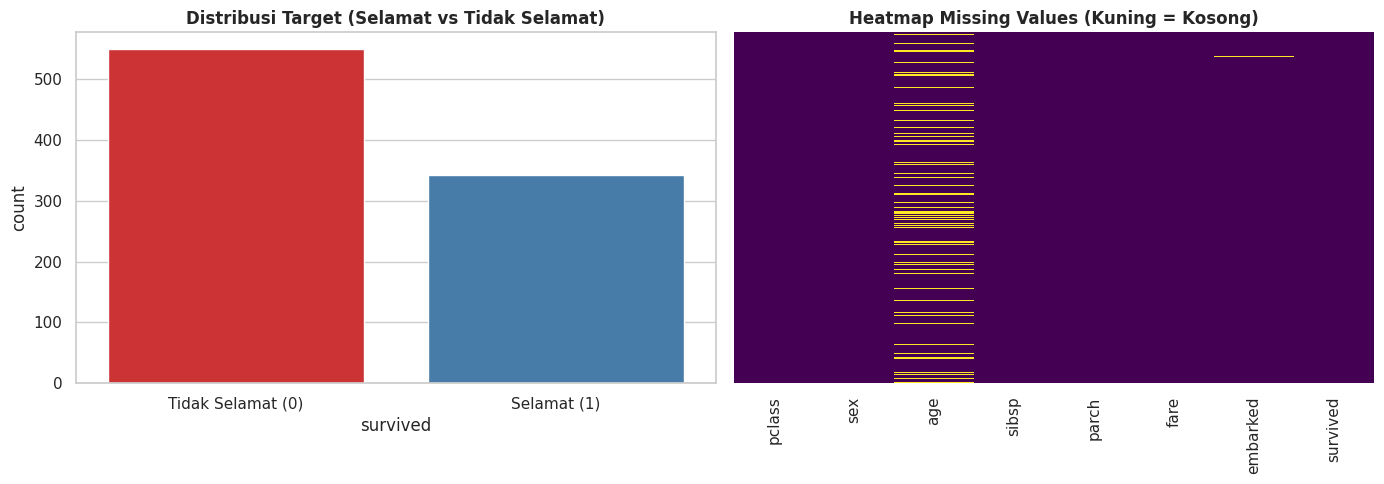

In [9]:
# 1. MUAT DATASET & EKSPLORASI AWAL (EDA)
print("=== LANGKAH 1: MUAT DATA & EKSPLORASI AWAL (EDA) ===")
# Memuat dataset Titanic bawaan dari seaborn
df = sns.load_dataset('titanic')[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']]

print("1. Info & Tipe Data:")
df.info()

print("\n2. Missing Values (Data Kosong):")
print(df.isnull().sum())

print("\n3. Distribusi Target (Survived):")
print(df['survived'].value_counts(normalize=True).round(3))

# Grafik EDA Langkah 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='survived', palette='Set1', ax=axes[0])
axes[0].set_title('Distribusi Target (Selamat vs Tidak Selamat)', fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Tidak Selamat (0)', 'Selamat (1)'])

sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
axes[1].set_title('Heatmap Missing Values (Kuning = Kosong)', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# 2. IMPUTASI MISSING VALUES (SEBELUM ENCODING)
print("\n=== LANGKAH 2: IMPUTASI MISSING VALUES ===")
# Pisahkan nama kolom berdasarkan tipe datanya
kolom_numerik = ['age', 'fare'] # pclass, sibsp, parch diasumsikan tidak memiliki missing value
kolom_kategorikal = ['sex', 'embarked']

# 2a. Isi nilai numerik yang hilang dengan MEDIAN (tahan outlier)
for col in kolom_numerik:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 2b. Isi nilai kategorikal yang hilang dengan MODUS (nilai yang paling sering muncul)
for col in kolom_kategorikal:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Data kosong telah diisi! Cek ulang missing values:")
print(df.isnull().sum())


=== LANGKAH 2: IMPUTASI MISSING VALUES ===
✅ Data kosong telah diisi! Cek ulang missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


Langkah 2 (Imputasi sebelum OHE & Standarisasi): Kita menggunakan Median untuk mengisi usia (age) karena jika ada penumpang dengan usia ekstrem (outlier), nilai median tidak akan bergeser (tahan goyangan), berbeda dengan Mean (rata-rata) yang sangat mudah rusak oleh outlier.

In [11]:
# 3. ONE-HOT ENCODING (OHE)
print("\n=== LANGKAH 3: ONE-HOT ENCODING (OHE) ===")
# Terapkan OHE dengan drop_first=True untuk menghindari Dummy Variable Trap
df_encoded = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

print("✅ OHE Berhasil! Kolom 'sex' dan 'embarked' telah diubah menjadi biner.")
print(f"Daftar Kolom Baru: {list(df_encoded.columns)}")
display(df_encoded.head(3))


=== LANGKAH 3: ONE-HOT ENCODING (OHE) ===
✅ OHE Berhasil! Kolom 'sex' dan 'embarked' telah diubah menjadi biner.
Daftar Kolom Baru: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True


Langkah 3 (Menghindari Dummy Trap): Pada OHE, kita menggunakan argumen drop_first=True. Ini berarti jika sex terdiri dari Male dan Female, kita cukup menyisakan kolom sex_male. Kenapa? Karena jika sex_male = 0, model secara otomatis tahu bahwa itu pasti Female. Menyimpan kedua kolom justru akan membingungkan perhitungan model linear (Multicollinearity).

In [12]:
# 4. TRAIN-TEST SPLIT DENGAN STRATIFIKASI
print("\n=== LANGKAH 4: PEMBAGIAN DATA (TRAIN-TEST SPLIT) ===")
X = df_encoded.drop('survived', axis=1)
y = df_encoded['survived']

# Stratify=y memastikan proporsi survived (0=61.6%, 1=38.4%) tetap sama di train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data Latih (Train) : {X_train.shape[0]} baris")
print(f"Data Uji (Test)    : {X_test.shape[0]} baris")
print("\nBukti Stratifikasi Berhasil (Proporsi Target y):")
print("Train Set:\n", y_train.value_counts(normalize=True).round(3))
print("Test Set:\n", y_test.value_counts(normalize=True).round(3))


=== LANGKAH 4: PEMBAGIAN DATA (TRAIN-TEST SPLIT) ===
Data Latih (Train) : 712 baris
Data Uji (Test)    : 179 baris

Bukti Stratifikasi Berhasil (Proporsi Target y):
Train Set:
 survived
0    0.617
1    0.383
Name: proportion, dtype: float64
Test Set:
 survived
0    0.615
1    0.385
Name: proportion, dtype: float64


Langkah 4 (Stratified Split): Target keselamatan Titanic tidak seimbang (61% tewas, 38% selamat). Jika kita memotong data secara acak tanpa stratify=y, bisa jadi data uji (test set) kita isinya orang tewas semua. Stratifikasi menjamin pembagian rasio 61:38 yang adil di kedua sisi data latih dan uji.

In [13]:
# 5. STANDARD SCALER HANYA PADA KOLOM NUMERIK ───────────────
print("\n=== LANGKAH 5: STANDARD SCALER ===")
scaler = StandardScaler()

# Tentukan kolom numerik murni yang butuh di-scale (Hindari kolom OHE/biner)
fitur_numerik = ['pclass', 'age', 'sibsp', 'parch', 'fare']

# Buat salinan agar tidak mengubah data asli
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# PENTING: Fit HANYA pada X_train, Transform pada X_train dan X_test
X_train_scaled[fitur_numerik] = scaler.fit_transform(X_train[fitur_numerik])
X_test_scaled[fitur_numerik] = scaler.transform(X_test[fitur_numerik])

print("✅ Standarisasi Berhasil! Kolom numerik kini memiliki skala rata-rata 0.")
print("Contoh Data X_train_scaled (Perhatikan kolom numerik berubah, kolom biner OHE tetap 0/1):")
display(X_train_scaled.head())


=== LANGKAH 5: STANDARD SCALER ===
✅ Standarisasi Berhasil! Kolom numerik kini memiliki skala rata-rata 0.
Contoh Data X_train_scaled (Perhatikan kolom numerik berubah, kolom biner OHE tetap 0/1):


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
692,0.829568,-0.112078,-0.465084,-0.466183,0.513812,True,False,True
481,-0.370945,-0.112078,-0.465084,-0.466183,-0.662563,True,False,True
527,-1.571457,-0.112078,-0.465084,-0.466183,3.955399,True,False,True
855,0.829568,-0.879807,-0.465084,0.727782,-0.467874,False,False,True
801,-0.370945,0.118241,0.478335,0.727782,-0.115977,False,False,True


Langkah 5 (StandardScaler & Data Leakage): Kita DILARANG KERAS menggunakan fit scaler pada X_test. Model tidak boleh "mengintip" distribusi data ujian. Karena itu kita memakai metode .fit_transform() pada X_train, dan hanya menggunakan .transform() pada X_test menggunakan patokan yang dipelajari dari data latih. Kita juga mengecualikan kolom biner hasil OHE (seperti sex_male) dari scaler agar nilainya tetap murni $0$ dan $1$.